# Credal Sets — Updated Infrastructure & Dissertation Experiments

This notebook replaces the earlier **legacy 2D / critic-based** report with a notebook that matches the **current repository layout**, the **Bayesian German-credit pipeline**, and the latest dissertation-facing experiment summaries.

## What changed

- The old notebook was built around the legacy `out_fm_solver/manifest.txt` + `credal_run.sh` + 2D scatter/KL workflow.
- The current repo now has a **Bayesian pipeline** for real-data prior uncertainty, centered on:
  - `train_bayesian.py`
  - `evaluation_predictive.py`
  - `run_german_credit_end2end.sh`
  - `weight_opt/run_repeats_bayesian.py`
  - experiment outputs such as `out_fm_solver_mt75/`
- The main empirical focus is now **German credit in the low-data regime (`n_train = 75`)**, with predictive log-likelihood / NLL rather than KDE-based evaluation.

## What this notebook now does

1. Scans the repo for the **new infrastructure** and output folders.
2. Summarises the **current experiment registry**.
3. Rebuilds the key **German credit low-data** result tables and figures.
4. Shows the **full-data null control** and the **Radon MN** result.
5. Provides an **optional live loader** for the latest aggregate CSVs if they are present locally.

> The notebook is designed to be useful even before every output directory is present locally. When files are available, the loader cells will pick them up automatically; otherwise the hard-coded dissertation summary tables still render the main story.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

REPO_ROOT = Path('.').resolve()
print('Repo root assumed by notebook:', REPO_ROOT)

Repo root assumed by notebook: /Users/xtricity/Desktop/Robust-Variational-Inferences


## 1. Current repo infrastructure

The current repo has **two distinct tracks**.

### Legacy / synthetic / 2D track
- `train_flow.py`
- `sample_flow.py`
- `evaluation_nll.py`
- `run_all.sh`
- `credal_run.sh`

This track is still useful for toy manifolds and early sanity checks, but its old critic-based mixture optimisation is no longer the dissertation centrepiece.

### Current Bayesian / dissertation track
- `train_bayesian.py` — shared prior-conditioned flow for Bayesian problems
- `datasets/german_credit.py` — 25D Bayesian logistic regression setup
- `evaluation_predictive.py` — predictive evaluation for higher-dimensional Bayesian tasks
- `weight_opt/run_repeats_bayesian.py` — repeated direct weight optimisation across algorithms
- `run_german_credit_end2end.sh` — end-to-end German-credit experiment driver
- `out_fm_solver_mt75/` — low-data German-credit output archive

The key conceptual update is that the model is no longer only a 2D density visualiser; it is now a **shared prior-conditioned posterior approximator** used to study prior uncertainty under predictive evaluation.

In [2]:
KEY_PATHS = [
    'train_flow.py',
    'sample_flow.py',
    'evaluation_nll.py',
    'train_bayesian.py',
    'evaluation_predictive.py',
    'run_all.sh',
    'credal_run.sh',
    'run_german_credit_end2end.sh',
    'dissertation_results_complete.md',
    'datasets',
    'weight_opt',
    'out_fm_solver',
    'out_fm_solver_mt75',
]

scan_rows = []
for rel in KEY_PATHS:
    p = REPO_ROOT / rel
    scan_rows.append({
        'path': rel,
        'exists': p.exists(),
        'type': 'dir' if p.is_dir() else ('file' if p.exists() else 'missing')
    })

scan_df = pd.DataFrame(scan_rows)
display(scan_df)

latest_weight_dirs = []
for parent in [REPO_ROOT / 'out_fm_solver' / 'weight_experiments', REPO_ROOT / 'out_fm_solver_mt75' / 'weight_experiments']:
    if parent.exists():
        for child in sorted(parent.iterdir()):
            if child.is_dir():
                latest_weight_dirs.append(str(child.relative_to(REPO_ROOT)))

if latest_weight_dirs:
    print('Detected weight-experiment directories:')
    for item in latest_weight_dirs[-10:]:
        print(' -', item)
else:
    print('No local weight_experiments directories detected in the current working copy.')

,path,exists,type
0,train_flow.py,True,file
1,sample_flow.py,True,file
2,evaluation_nll.py,True,file
3,train_bayesian.py,True,file
4,evaluation_predictive.py,True,file
5,run_all.sh,True,file
6,credal_run.sh,True,file
7,run_german_credit_end2end.sh,True,file
8,dissertation_results_complete.md,True,file
9,datasets,True,dir


Detected weight-experiment directories:
 - out_fm_solver/weight_experiments/german_credit_repeats_20260323_162528
 - out_fm_solver/weight_experiments/german_credit_repeats_20260323_163734
 - out_fm_solver/weight_experiments/german_credit_repeats_20260323_165016
 - out_fm_solver/weight_experiments/german_credit_repeats_20260323_172732
 - out_fm_solver/weight_experiments/radon_mn_val_repeats_20260227_141904
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_115426
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_120517
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_121936
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_122950
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_124032


## 2. Experiment registry

This is the dissertation-facing experiment inventory reflected in the current repo and results summary.

- **Synthetic 2D datasets** (`eight_ring`, `moons`, `spirals`): useful for diagnostics, but the old critic-based mixture results need re-running with direct held-out-NLL optimisation.
- **Radon MN**: real data, 2D, moderate sample size; little prior sensitivity.
- **German credit (full data, `n_train = 700`)**: expected null control where prior sensitivity largely disappears.
- **German credit (low data, `n_train = 75`)**: flagship experiment, because prior choice becomes genuinely consequential.

In [3]:
experiment_registry = pd.DataFrame([
    {
        'experiment': 'Synthetic (eight_ring / moons / spirals)',
        'dim': 2,
        'n_train': '∞ / generated',
        'K_priors': 5,
        'seeds': 10,
        'metric': 'KDE-NLL',
        'status': 'Legacy critic-based; re-run needed',
        'headline': 'Flow family works; old mixture optimiser is not final evidence.'
    },
    {
        'experiment': 'Radon MN',
        'dim': 2,
        'n_train': '~620',
        'K_priors': 3,
        'seeds': 10,
        'metric': 'KDE-NLL',
        'status': 'Current direct-NLL result',
        'headline': 'Gaussian dominates; weak prior sensitivity.'
    },
    {
        'experiment': 'German credit (full data)',
        'dim': 25,
        'n_train': 700,
        'K_priors': 5,
        'seeds': 10,
        'metric': 'Predictive NLL / LL',
        'status': 'Current Bayesian result',
        'headline': 'Null control: all priors nearly converge.'
    },
    {
        'experiment': 'German credit (low data)',
        'dim': 25,
        'n_train': 75,
        'K_priors': 5,
        'seeds': 5,
        'metric': 'Predictive NLL / LL',
        'status': 'Primary result',
        'headline': 'Best prior changes by seed; mixture is near-oracle.'
    },
])

display(experiment_registry)

,experiment,dim,n_train,K_priors,seeds,metric,status,headline
0,Synthetic (eight_ring / moons / spirals),2,∞ / generated,5,10,KDE-NLL,Legacy critic-based; re-run needed,Flow family works; old mixture optimiser is no...
1,Radon MN,2,~620,3,10,KDE-NLL,Current direct-NLL result,Gaussian dominates; weak prior sensitivity.
2,German credit (full data),25,700,5,10,Predictive NLL / LL,Current Bayesian result,Null control: all priors nearly converge.
3,German credit (low data),25,75,5,5,Predictive NLL / LL,Primary result,Best prior changes by seed; mixture is near-or...


## 3. German credit low-data (`n_train = 75`) — primary result

This is the main dissertation experiment because it simultaneously gives you:

- a **real dataset**,
- a **genuinely prior-sensitive low-data regime**,
- a **shared flow-matching posterior family**, and
- a clean **minimax-regret story**.

The important claim is not merely “the mixture slightly improves the mean”. The stronger and more defensible claim is:

> **No fixed prior is uniformly safe, while EM-style credal selection is near-oracle and has extremely low worst-case regret.**

,seed_0,seed_1,seed_2,seed_3,seed_4,mean
algorithm,,,,,,
em,0.6307,0.6214,0.6169,0.5976,0.6461,0.6225
proj_gd,0.6310,0.6215,0.6176,0.5972,0.6464,0.6227
coord,0.6312,0.6215,0.6175,0.5971,0.6468,0.6228
grid,0.6312,0.6215,0.6175,0.5971,0.6467,0.6228
frank_wolfe,0.6312,0.6215,0.6175,0.5971,0.6468,0.6228
best_single,0.6333,0.6222,0.6175,0.5971,0.6500,0.6240
mirror,0.6380,0.6324,0.6258,0.6115,0.6546,0.6325
uniform,0.6753,0.6735,0.6671,0.6473,0.6881,0.6703


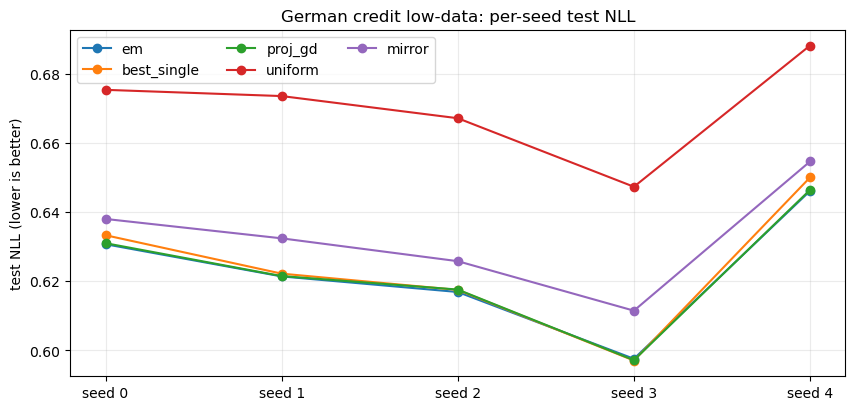

In [4]:
low_data_nll = pd.DataFrame({
    'algorithm': ['em', 'proj_gd', 'coord', 'grid', 'frank_wolfe', 'best_single', 'mirror', 'uniform'],
    'seed_0': [0.6307, 0.6310, 0.6312, 0.6312, 0.6312, 0.6333, 0.6380, 0.6753],
    'seed_1': [0.6214, 0.6215, 0.6215, 0.6215, 0.6215, 0.6222, 0.6324, 0.6735],
    'seed_2': [0.6169, 0.6176, 0.6175, 0.6175, 0.6175, 0.6175, 0.6258, 0.6671],
    'seed_3': [0.5976, 0.5972, 0.5971, 0.5971, 0.5971, 0.5971, 0.6115, 0.6473],
    'seed_4': [0.6461, 0.6464, 0.6468, 0.6467, 0.6468, 0.6500, 0.6546, 0.6881],
}).set_index('algorithm')
low_data_nll['mean'] = low_data_nll.mean(axis=1)
display(low_data_nll.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
for alg in ['em', 'best_single', 'proj_gd', 'uniform', 'mirror']:
    ax.plot(range(5), low_data_nll.loc[alg, [f'seed_{i}' for i in range(5)]], marker='o', label=alg)
ax.set_xticks(range(5))
ax.set_xticklabels([f'seed {i}' for i in range(5)])
ax.set_ylabel('test NLL (lower is better)')
ax.set_title('German credit low-data: per-seed test NLL')
ax.legend(ncol=3, frameon=True)
plt.show()

,seed_0,seed_1,seed_2,seed_3,seed_4,max_regret,mean_regret
algorithm,,,,,,,
em,0.0000,0.0000,0.0000,0.0005,0.0000,0.0005,0.0001
grid,0.0005,0.0001,0.0006,0.0000,0.0006,0.0006,0.0004
proj_gd,0.0003,0.0001,0.0007,0.0001,0.0003,0.0007,0.0003
coord,0.0005,0.0001,0.0006,0.0000,0.0007,0.0007,0.0004
frank_wolfe,0.0005,0.0001,0.0006,0.0000,0.0007,0.0007,0.0004
best_single,0.0026,0.0008,0.0006,0.0000,0.0039,0.0039,0.0016
mirror,0.0073,0.0110,0.0089,0.0144,0.0085,0.0144,0.0100
uniform,0.0446,0.0521,0.0502,0.0502,0.0420,0.0521,0.0478


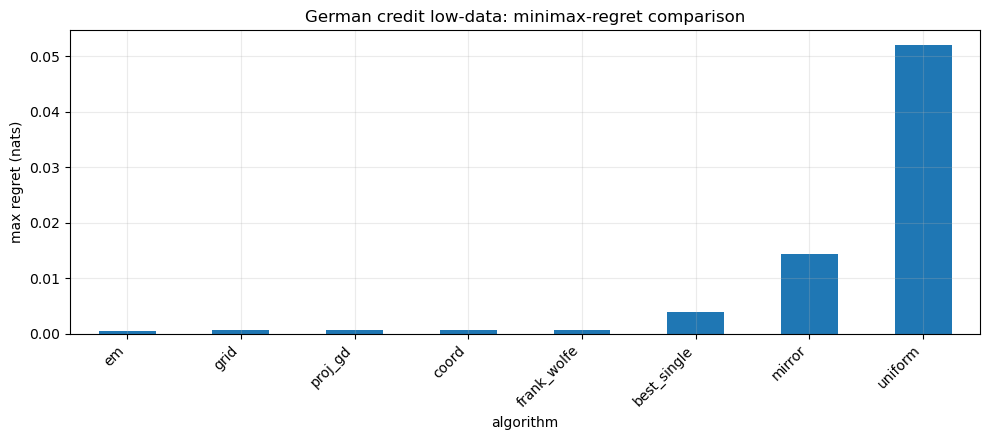

In [5]:
oracle_nll = pd.Series({'seed_0': 0.6307, 'seed_1': 0.6214, 'seed_2': 0.6169, 'seed_3': 0.5971, 'seed_4': 0.6461})
regret = low_data_nll[[f'seed_{i}' for i in range(5)]].sub(oracle_nll, axis=1)
regret['max_regret'] = regret.max(axis=1)
regret['mean_regret'] = regret[[f'seed_{i}' for i in range(5)]].mean(axis=1)
regret = regret.sort_values(['max_regret', 'mean_regret'])
display(regret.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
regret['max_regret'].plot(kind='bar', ax=ax)
ax.set_ylabel('max regret (nats)')
ax.set_title('German credit low-data: minimax-regret comparison')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,gaussian,laplace,cauchy,student_t,gaussian_wide,best_prior
seed,,,,,,
0,-0.630,-0.633,-0.695,-0.718,-0.823,gaussian
1,-0.622,-0.624,-0.690,-0.711,-0.888,gaussian
2,-0.616,-0.618,-0.711,-0.696,-0.853,gaussian
3,-0.609,-0.597,-0.685,-0.683,-0.793,laplace
4,-0.650,-0.644,-0.725,-0.716,-0.790,laplace


,max_regret,mean_regret
laplace,0.003,0.001
gaussian,0.012,0.004
student_t,0.089,0.083
cauchy,0.095,0.079
gaussian_wide,0.266,0.208


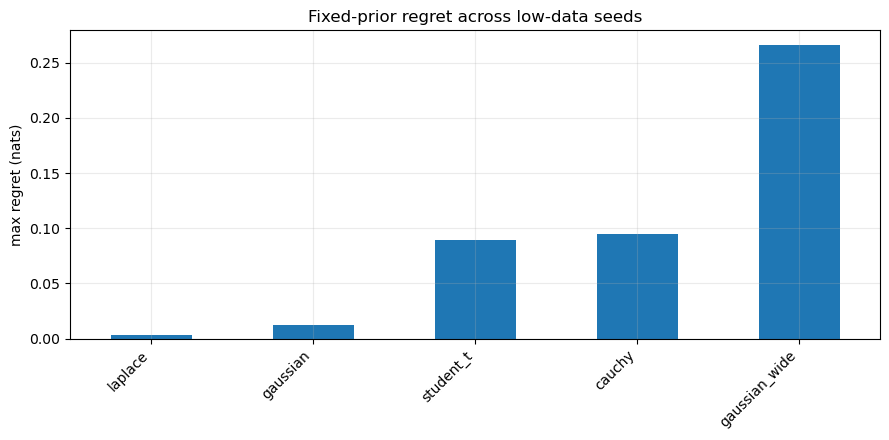

In [6]:
prior_pred_ll = pd.DataFrame({
    'seed': [0, 1, 2, 3, 4],
    'gaussian':      [-0.630, -0.622, -0.616, -0.609, -0.650],
    'laplace':       [-0.633, -0.624, -0.618, -0.597, -0.644],
    'cauchy':        [-0.695, -0.690, -0.711, -0.685, -0.725],
    'student_t':     [-0.718, -0.711, -0.696, -0.683, -0.716],
    'gaussian_wide': [-0.823, -0.888, -0.853, -0.793, -0.790],
}).set_index('seed')

prior_winners = prior_pred_ll.idxmax(axis=1).rename('best_prior')
display(pd.concat([prior_pred_ll, prior_winners], axis=1))

fixed_prior_nll = -prior_pred_ll
fixed_oracle = fixed_prior_nll.min(axis=1)
fixed_regret = fixed_prior_nll.sub(fixed_oracle, axis=0)
fixed_summary = pd.DataFrame({
    'max_regret': fixed_regret.max(axis=0),
    'mean_regret': fixed_regret.mean(axis=0),
}).sort_values('max_regret')
display(fixed_summary.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
fixed_summary['max_regret'].plot(kind='bar', ax=ax)
ax.set_ylabel('max regret (nats)')
ax.set_title('Fixed-prior regret across low-data seeds')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Control experiments

The low-data result matters more because it has a built-in contrast with two regimes where prior uncertainty is much less consequential.

### German credit, full data (`n_train = 700`)
A null control. With much more data, likelihood dominates and all reasonable priors induce almost the same predictive performance.

### Radon MN
A real-data 2D case where Gaussian already dominates and the mixture cannot do much beyond matching it.

,experiment,algorithm,mean_test_nll,std
0,German credit (full data),proj_gd,0.4981,0.0003
1,German credit (full data),grid,0.4985,0.0007
2,German credit (full data),coord,0.4985,0.0007
3,German credit (full data),frank_wolfe,0.4985,0.0007
4,German credit (full data),best_single,0.4990,0.0011
5,German credit (full data),em,0.4991,0.0001
6,German credit (full data),mirror,0.4999,0.0001
7,German credit (full data),uniform,0.5000,0.0001
8,Radon MN,best_single,2.5141,0.0085
9,Radon MN,grid,2.5141,0.0085


experiment,German credit (full data),Radon MN
algorithm,,
best_single,0.4990,2.5141
coord,0.4985,2.5141
em,0.4991,2.5146
frank_wolfe,0.4985,2.5141
grid,0.4985,2.5141
mirror,0.4999,2.5224
proj_gd,0.4981,2.5141
uniform,0.5000,2.5257


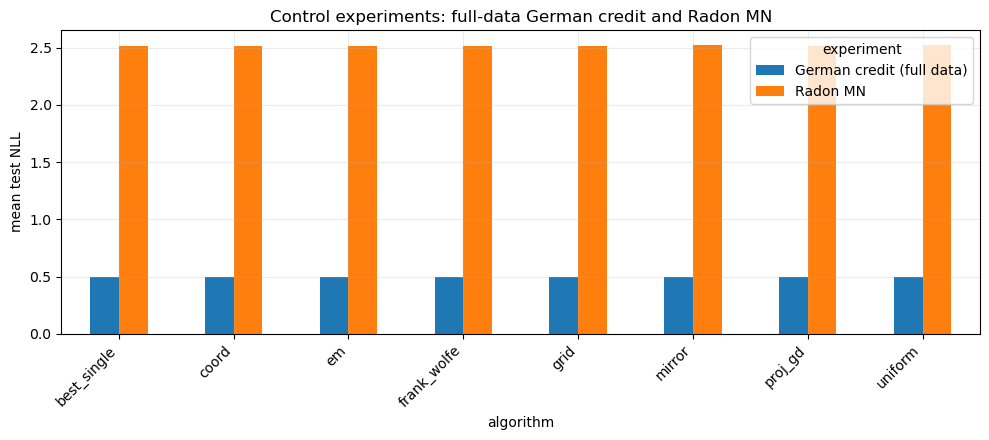

In [7]:
control_summary = pd.DataFrame([
    {'experiment': 'German credit (full data)', 'algorithm': 'proj_gd',     'mean_test_nll': 0.4981, 'std': 0.0003},
    {'experiment': 'German credit (full data)', 'algorithm': 'grid',        'mean_test_nll': 0.4985, 'std': 0.0007},
    {'experiment': 'German credit (full data)', 'algorithm': 'coord',       'mean_test_nll': 0.4985, 'std': 0.0007},
    {'experiment': 'German credit (full data)', 'algorithm': 'frank_wolfe', 'mean_test_nll': 0.4985, 'std': 0.0007},
    {'experiment': 'German credit (full data)', 'algorithm': 'best_single', 'mean_test_nll': 0.4990, 'std': 0.0011},
    {'experiment': 'German credit (full data)', 'algorithm': 'em',          'mean_test_nll': 0.4991, 'std': 0.0001},
    {'experiment': 'German credit (full data)', 'algorithm': 'mirror',      'mean_test_nll': 0.4999, 'std': 0.0001},
    {'experiment': 'German credit (full data)', 'algorithm': 'uniform',     'mean_test_nll': 0.5000, 'std': 0.0001},
    {'experiment': 'Radon MN',                  'algorithm': 'best_single', 'mean_test_nll': 2.5141, 'std': 0.0085},
    {'experiment': 'Radon MN',                  'algorithm': 'grid',        'mean_test_nll': 2.5141, 'std': 0.0085},
    {'experiment': 'Radon MN',                  'algorithm': 'coord',       'mean_test_nll': 2.5141, 'std': 0.0085},
    {'experiment': 'Radon MN',                  'algorithm': 'proj_gd',     'mean_test_nll': 2.5141, 'std': 0.0084},
    {'experiment': 'Radon MN',                  'algorithm': 'frank_wolfe', 'mean_test_nll': 2.5141, 'std': 0.0085},
    {'experiment': 'Radon MN',                  'algorithm': 'em',          'mean_test_nll': 2.5146, 'std': 0.0085},
    {'experiment': 'Radon MN',                  'algorithm': 'mirror',      'mean_test_nll': 2.5224, 'std': 0.0087},
    {'experiment': 'Radon MN',                  'algorithm': 'uniform',     'mean_test_nll': 2.5257, 'std': 0.0088},
])

display(control_summary)

pivot = control_summary.pivot(index='algorithm', columns='experiment', values='mean_test_nll')
display(pivot.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('mean test NLL')
ax.set_title('Control experiments: full-data German credit and Radon MN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Why flow matching is still justified here

The justification is now much sharper than “flows are flexible”.

### Methodological role
Flow matching gives you a **single expressive prior-conditioned posterior family** shared across priors. That matters because the dissertation question is about **uncertainty over priors**, not about comparing unrelated approximate families trained separately.

### Practical role
The new Bayesian pipeline uses:
- prior-dependent training targets,
- a shared conditional flow architecture,
- predictive evaluation instead of KDE in higher dimensions.

So flow matching is not just a generic density model here; it is the mechanism that makes **coherent credal comparison across priors** feasible in a shared approximation class.

A good one-line summary for the dissertation is:

> We use flow matching because it provides a single expressive posterior family conditioned on prior identity, allowing credal selection to reflect prior uncertainty rather than arbitrary differences in model class.

## 6. Optional live loader for local repo outputs

If you are running this notebook from the actual repo root and the result folders are present, the following cell will try to load the latest available `aggregate.csv` / `per_run.csv` files from:

- `out_fm_solver/weight_experiments/...`
- `out_fm_solver_mt75/weight_experiments/...`

This is intentionally optional, because the notebook should still be readable when only the source tree is present.

In [8]:
def find_latest_csvs(repo_root: Path):
    hits = []
    patterns = [
        'out_fm_solver/weight_experiments/*/aggregate.csv',
        'out_fm_solver/weight_experiments/*/per_run.csv',
        'out_fm_solver_mt75/weight_experiments/*/aggregate.csv',
        'out_fm_solver_mt75/weight_experiments/*/per_run.csv',
    ]
    for pattern in patterns:
        hits.extend(sorted(repo_root.glob(pattern)))
    return hits

csv_hits = find_latest_csvs(REPO_ROOT)
if not csv_hits:
    print('No aggregate/per_run CSVs detected locally.')
else:
    latest = sorted(csv_hits, key=lambda p: p.stat().st_mtime)
    print('Newest CSV files detected:')
    for p in latest[-6:]:
        print(' -', p.relative_to(REPO_ROOT))

    for p in latest[-2:]:
        print('')
        print('=== Preview:', p.relative_to(REPO_ROOT), '===')
        try:
            df = pd.read_csv(p)
            display(df.head())
        except Exception as e:
            print('Could not read', p, ':', e)

Newest CSV files detected:
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_121936/per_run.csv
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_121936/aggregate.csv
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_122950/per_run.csv
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_122950/aggregate.csv
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_124032/per_run.csv
 - out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_124032/aggregate.csv

=== Preview: out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_124032/per_run.csv ===


,run,seed,algo,nll_train,nll_val,nll_test,weights
0,0,0,uniform,0.351643,0.706414,0.681853,gaussian:0.2000 gaussian_wide:0.2000 cauchy:0....
1,1,1,uniform,0.351475,0.706014,0.681118,gaussian:0.2000 gaussian_wide:0.2000 cauchy:0....
2,2,2,uniform,0.351706,0.707234,0.681052,gaussian:0.2000 gaussian_wide:0.2000 cauchy:0....
3,3,3,uniform,0.351108,0.708662,0.681720,gaussian:0.2000 gaussian_wide:0.2000 cauchy:0....
4,4,4,uniform,0.351362,0.707499,0.682427,gaussian:0.2000 gaussian_wide:0.2000 cauchy:0....



=== Preview: out_fm_solver_mt75/weight_experiments/german_credit_repeats_20260324_124032/aggregate.csv ===


,algo,nll_train_mean,nll_train_std,nll_val_mean,nll_val_std,nll_test_mean,nll_test_std
0,uniform,0.351459,0.000239,0.707165,0.001030,0.681634,0.000568
1,best_single,0.371185,0.000602,0.654197,0.001793,0.652330,0.000878
2,grid,0.371185,0.000602,0.654197,0.001793,0.652330,0.000878
3,em,0.371399,0.000485,0.654811,0.001899,0.652586,0.000877
4,proj_gd,0.371112,0.000596,0.654309,0.001776,0.652379,0.000862


In [9]:
import os
import pandas as pd

BASE = "out_fm_solver/weight_experiments_fixed"
datasets = ["eight_ring", "moons", "spirals"]
seeds = list(range(10))

all_rows = []

for d in datasets:
    for s in seeds:
        path = f"{BASE}/{d}_repeats_{d}_seed{s}/aggregate.csv"
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["dataset"] = d
            df["seed"] = s
            all_rows.append(df)

full_df = pd.concat(all_rows, ignore_index=True)
full_df.head()

,algo,nll_train_mean,nll_train_std,nll_val_mean,nll_val_std,nll_test_mean,nll_test_std,dataset,seed
0,uniform,2.015968,0.005206,2.019669,0.006131,2.018311,0.006305,eight_ring,0
1,best_single,1.982344,0.004715,1.985400,0.006341,1.983243,0.005177,eight_ring,0
2,grid,1.982344,0.004715,1.985400,0.006341,1.983243,0.005177,eight_ring,0
3,em,1.983028,0.004533,1.986053,0.006414,1.983958,0.005066,eight_ring,0
4,proj_gd,1.982523,0.004651,1.985581,0.006372,1.983431,0.005172,eight_ring,0


In [10]:
# get best_single per dataset/seed
best = full_df[full_df["algo"] == "best_single"][
    ["dataset", "seed", "nll_test_mean"]
].rename(columns={"nll_test_mean": "best_single_nll"})

merged = full_df.merge(best, on=["dataset", "seed"])
merged["delta_vs_best"] = merged["nll_test_mean"] - merged["best_single_nll"]

merged.head()

,algo,nll_train_mean,nll_train_std,nll_val_mean,nll_val_std,nll_test_mean,nll_test_std,dataset,seed,best_single_nll,delta_vs_best
0,uniform,2.015968,0.005206,2.019669,0.006131,2.018311,0.006305,eight_ring,0,1.983243,0.035068
1,best_single,1.982344,0.004715,1.985400,0.006341,1.983243,0.005177,eight_ring,0,1.983243,0.000000
2,grid,1.982344,0.004715,1.985400,0.006341,1.983243,0.005177,eight_ring,0,1.983243,0.000000
3,em,1.983028,0.004533,1.986053,0.006414,1.983958,0.005066,eight_ring,0,1.983243,0.000714
4,proj_gd,1.982523,0.004651,1.985581,0.006372,1.983431,0.005172,eight_ring,0,1.983243,0.000188


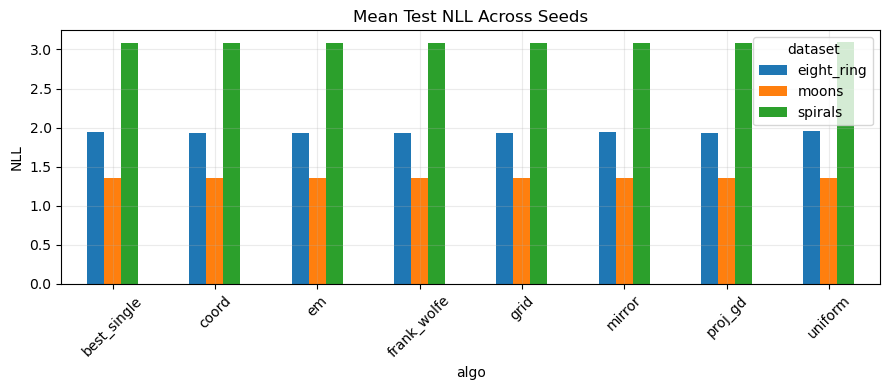

In [11]:
import matplotlib.pyplot as plt

mean_perf = merged.groupby(["dataset", "algo"])["nll_test_mean"].mean().unstack()

mean_perf.T.plot(kind="bar")
plt.title("Mean Test NLL Across Seeds")
plt.ylabel("NLL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

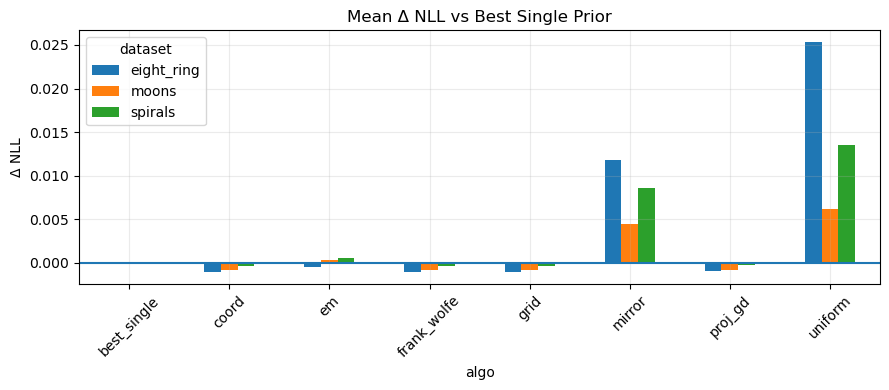

In [12]:
delta_mean = merged.groupby(["dataset", "algo"])["delta_vs_best"].mean().unstack()

delta_mean.T.plot(kind="bar")
plt.axhline(0)
plt.title("Mean Δ NLL vs Best Single Prior")
plt.ylabel("Δ NLL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

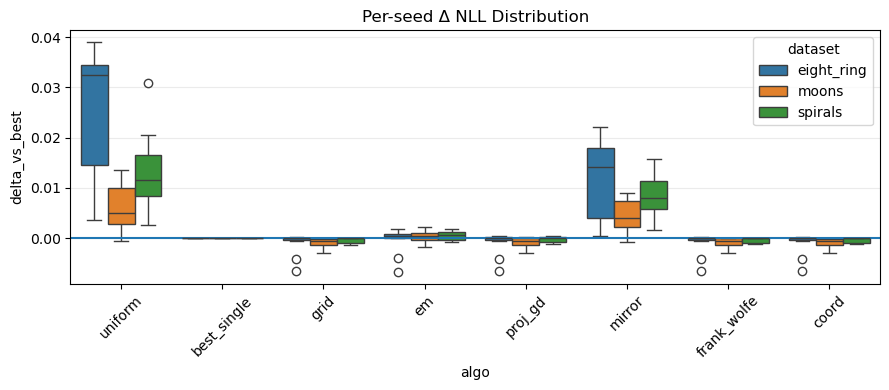

In [13]:
import seaborn as sns

sns.boxplot(
    data=merged,
    x="algo",
    y="delta_vs_best",
    hue="dataset"
)

plt.axhline(0)
plt.title("Per-seed Δ NLL Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
def win_stats(df):
    wins = (df["delta_vs_best"] < -1e-4).sum()
    ties = (df["delta_vs_best"].abs() <= 1e-4).sum()
    losses = (df["delta_vs_best"] > 1e-4).sum()
    return pd.Series({"wins": wins, "ties": ties, "losses": losses})

stats = merged.groupby(["dataset", "algo"]).apply(win_stats)
stats

/var/folders/4r/xyyg405d45b_dbmhstrpwbv80000gn/T/ipykernel_90028/1912507909.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = merged.groupby(["dataset", "algo"]).apply(win_stats)


wins  ties  losses
dataset    algo                           
eight_ring best_single     0    10       0
           coord           3     6       1
           em              2     1       7
           frank_wolfe     3     6       1
           grid            3     6       1
           mirror          0     0      10
           proj_gd         3     2       5
           uniform         0     0      10
moons      best_single     0    10       0
           coord           7     3       0
           em              4     1       5
           frank_wolfe     7     3       0
           grid            7     3       0
           mirror          1     0       9
           proj_gd         6     2       2
           uniform         1     0       9
spirals    best_single     0    10       0
           coord           4     6       0
           em              3     0       7
           frank_wolfe     4     5       1
           grid            4     6       0
           mirror          0     0      10
           proj_gd         4     1       5
           uniform         0     0      10

## 7. Recommended next edits after this notebook refresh

1. Add a loader for `dissertation_results_complete.md` if you want this notebook to ingest the markdown directly.
2. Add one more cell that reads the **latest `out_fm_solver_mt75` run** and renders the learned weights per algorithm.
3. If the synthetic reruns finish, add a final section replacing the legacy critic-based synthetic summary with the new direct-NLL tables.
4. Once the remaining low-data seeds are complete, expand the main result section from **5 seeds to 10 seeds** and update the regret figures.

For the dissertation itself, the clearest main claim remains:

> In the low-data German-credit regime, the identity of the best prior changes across seeds, so no fixed prior is uniformly safe; EM-style credal selection is near-oracle and minimax-robust.